# Exploratory Data Analysis

This notebook explores the cleaned tables from `data/03_cleaning/` to characterize
distributions, identify patterns, and develop features for the pre/post analysis
in `05_analysis.ipynb`. The pre/post split is 2020–2024 (baseline) vs. 2025 (treatment).

**Analytical scope:** WFO-level analysis is restricted to the **top quartile of offices
by baseline event volume** (p75+, 2020–2024) for each phenomena. Low-volume offices
produce unreliable annual and monthly verify rates; restricting to high-volume offices
ensures metrics are statistically meaningful. A sensitivity check using all CONUS
offices is included in Section 5. Section 1 presents national totals for context.

## Data Dictionary

### events — 161,404 rows, one per warning event

| Field | Type | Nulls | Description | Analysis notes |
|---|---|---|---|---|
| `wfo` | str | 0 | NWS Weather Forecast Office call sign (e.g. `OUN`) | 122 offices; consider CONUS-only filter for main analysis |
| `year` | int | 0 | Calendar year 2020–2025 | Pre: 2020–2024; Post: 2025 |
| `phenomena` | str | 0 | VTEC code: `TO`, `SV`, or `FF` | Always split metrics by phenomena — performance baselines differ substantially |
| `eventid` | int | 0 | API event identifier; unique within WFO-year-phenomena | Use `product_id` for joins, not `eventid` alone |
| `product_id` | str | 0 | Derived join key: `{year}{wfo}{eventid}{phenomena}W1` | FK target for `stormreports.events`; 99.97% match rate |
| `issue` | datetime UTC | 0 | Warning issuance time | Use for time-of-day and seasonal stratification |
| `expire` | datetime UTC | 0 | Warning expiration time | — |
| `duration_min` | float | 0 | Warning duration in minutes (`expire − issue`) | Derived; check for 0-minute and extreme values |
| `status` | str | 0 | Terminal status: `EXP`, `CAN`, `COR`, `EXT`, `CON`, `NEW` | `CAN` = cancelled before expiry; relevant to FAR interpretation |
| `verify` | bool | 0 | `True` if ≥1 confirming LSR matched | Primary outcome for POD; 46.3% of events verified |
| `lead0` | float (min) | 53.7% | Lead time in minutes from warning issuance to first confirming LSR; 0 = warning issued in the same minute as LSR (POD₂ semantics) | Null iff `verify=False`; primary lead time metric; 5.4% of verified events have `lead0=0` (timestamp resolution artifact); capped at 99th pct per phenomena |
| `lead0_capped` | bool | 0 | `True` if `lead0` was capped | Exclude or flag capped rows in lead time distribution analysis |

### stormreports — 236,800 rows, one per Local Storm Report

| Field | Type | Nulls | Description | Analysis notes |
|---|---|---|---|---|
| `wfo` | str | 0 | NWS Weather Forecast Office call sign | — |
| `year` | int | 0 | Calendar year 2020–2025 | Pre: 2020–2024; Post: 2025 |
| `valid` | datetime UTC | 0 | Time the storm report was filed | — |
| `lsrtype` | str | 0 | LSR phenomena: `TO`, `SV`, or `FF` | Always split by lsrtype |
| `typetext` | str | 0 | Human-readable report type description | Useful for EDA; not needed for POD/FAR |
| `warned` | bool | 0 | `True` if a matching warning was in effect | Defines the warned/unwarned split for POD calculation |
| `leadtime` | float (min) | 23.2% | Minutes from warning issuance to report time | Null iff `warned=False`; capped at 99th pct per lsrtype; secondary to `events.lead0` |
| `leadtime_capped` | bool | 0 | `True` if `leadtime` was capped | Flag in any leadtime distribution analysis |
| `events` | str | 19.9% | Comma-separated VTEC product IDs of matched warnings | Null iff `warned=False`; links report to `events.product_id` |
| `tdq` | bool | 0 | "Too Difficult to Qualify" — NWS could not confirm hazardous event | Exclude from POD numerator; 1.9% of reports (concentrated in SV) |
| `source` | str | 0 | Normalized report source (e.g. `TRAINED SPOTTER`, `PUBLIC`) | Potential stratification variable for source-bias analysis |
| `city` | str | 0 | City of report location; Nominatim-imputed where originally null | — |
| `county` | str | 0 | County of report location; Nominatim-imputed where originally null | — |
| `state` | str | 0 | Two-letter state code | Contains junk values (`'  '`, `'X '`, `'XX'`) — clean before use |
| `lon0` | float | 0 | Longitude of report location (exact point geometry) | Retained for spatial EDA |
| `lat0` | float | 0 | Latitude of report location (exact point geometry) | Retained for spatial EDA |
| `remark` | str | 11.5% | Free-text observer narrative | Not used in quantitative analysis |


## Configuration

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (12, 4)

CLEAN_DIR = Path("../data/03_cleaning")
IMG_DIR   = Path("../img")
IMG_DIR.mkdir(exist_ok=True)

events = pd.read_csv(CLEAN_DIR / "events.csv")
sr     = pd.read_csv(CLEAN_DIR / "stormreports.csv")

events["issue"] = pd.to_datetime(events["issue"], utc=True)
sr["valid"]     = pd.to_datetime(sr["valid"],     utc=True)

events["year_month"] = events["issue"].dt.to_period("M")
sr["year_month"]     = sr["valid"].dt.to_period("M")

# Treatment timeline reference points
CUT_DATE    = pd.Timestamp("2025-02-27")  # probationary terminations
DEPART_DATE = pd.Timestamp("2025-04-01")  # deferred resignations effective
REHIRE_DATE = pd.Timestamp("2025-08-01")  # partial rehiring wave

NON_CONUS = {"GUM", "HFO", "AFC", "AJK", "PPG", "AFG", "AER"}
PHENOMENA_LABELS = {"TO": "Tornado", "SV": "Severe Thunderstorm", "FF": "Flash Flood"}

# ── Top-quartile WFO sets (p75 of mean annual events, 2020-2024 baseline) ──
wfo_annual = (
    events[~events["wfo"].isin(NON_CONUS)]
    .groupby(["wfo", "year", "phenomena"])
    .size()
    .reset_index(name="n_events")
)
wfo_baseline = (
    wfo_annual[wfo_annual["year"] <= 2024]
    .groupby(["wfo", "phenomena"])["n_events"]
    .mean()
    .reset_index(name="mean_annual_events")
)
wfo_baseline["non_conus"] = wfo_baseline["wfo"].isin(NON_CONUS)

p75_wfos = {}
for phen in ["TO", "SV", "FF"]:
    sub = wfo_baseline[wfo_baseline["phenomena"] == phen]
    p75 = sub["mean_annual_events"].quantile(0.75)
    p75_wfos[phen] = set(sub[sub["mean_annual_events"] >= p75]["wfo"])
    print(f"{PHENOMENA_LABELS[phen]:25s}  p75={p75:.0f}/yr  "
          f"top-quartile WFOs: {len(p75_wfos[phen])}")

print(f"\nevents:       {len(events):,} rows")
print(f"stormreports: {len(sr):,} rows")

Tornado                    p75=36/yr  top-quartile WFOs: 27
Severe Thunderstorm        p75=242/yr  top-quartile WFOs: 29
Flash Flood                p75=50/yr  top-quartile WFOs: 29

events:       161,404 rows
stormreports: 236,782 rows


## Descriptive Statistics

Summary statistics for the three primary outcome measures — **verify rate**,
**lead0** (lead time in minutes, verified events only), and **annual event
volume** — broken down by phenomena and pre/post period (2020–2024 baseline
vs. 2025 treatment). All CONUS events; no top-quartile filter applied here.

In [2]:
conus = events[~events["wfo"].isin(NON_CONUS)].copy()
conus["period"] = np.where(conus["issue"].dt.year <= 2024, "2020–2024", "2025")

# ── Table 1: Verify rate by phenomena × period ────────────────────────────
vr = (
    conus.groupby(["phenomena", "period"])["verify"]
    .agg(n_events="count", verify_rate="mean", verify_std="std")
    .reset_index()
)
vr["phenomena"] = vr["phenomena"].map(PHENOMENA_LABELS)
vr = vr.rename(columns={
    "phenomena":   "Phenomena",
    "period":      "Period",
    "n_events":    "N events",
    "verify_rate": "Verify rate (mean)",
    "verify_std":  "Verify rate (SD)",
})
vr["Verify rate (mean)"] = vr["Verify rate (mean)"].map("{:.3f}".format)
vr["Verify rate (SD)"]   = vr["Verify rate (SD)"].map("{:.3f}".format)
print("Table 1 — Verify Rate by Phenomena and Period (all CONUS events)\n")
print(vr.to_string(index=False))

# ── Table 2: Lead0 distribution by phenomena × period (verified events) ───
lead = (
    conus[conus["verify"] == True]
    .groupby(["phenomena", "period"])["lead0"]
    .agg(
        n_verified = "count",
        mean       = "mean",
        median     = "median",
        sd         = "std",
        p25        = lambda x: x.quantile(0.25),
        p75        = lambda x: x.quantile(0.75),
        p99        = lambda x: x.quantile(0.99),
    )
    .reset_index()
)
lead["phenomena"] = lead["phenomena"].map(PHENOMENA_LABELS)
lead = lead.rename(columns={
    "phenomena":  "Phenomena",
    "period":     "Period",
    "n_verified": "N verified",
    "mean":       "Mean (min)",
    "median":     "Median (min)",
    "sd":         "SD",
    "p25":        "p25",
    "p75":        "p75",
    "p99":        "p99",
})
for col in ["Mean (min)", "Median (min)", "SD", "p25", "p75", "p99"]:
    lead[col] = lead[col].map("{:.1f}".format)
print("\nTable 2 — Lead0 Distribution by Phenomena and Period (verified events only)\n")
print(lead.to_string(index=False))

# ── Table 3: Annual event volume by phenomena × period ────────────────────
vol = (
    conus.groupby(["phenomena", "period", "year"])
    .size()
    .reset_index(name="n_events")
    .groupby(["phenomena", "period"])["n_events"]
    .agg(mean_annual="mean", sd_annual="std", min_year="min", max_year="max")
    .reset_index()
)
vol["phenomena"] = vol["phenomena"].map(PHENOMENA_LABELS)
vol = vol.rename(columns={
    "phenomena":    "Phenomena",
    "period":       "Period",
    "mean_annual":  "Mean annual events",
    "sd_annual":    "SD",
    "min_year":     "Min year",
    "max_year":     "Max year",
})
for col in ["Mean annual events", "SD"]:
    vol[col] = vol[col].map("{:.0f}".format)
print("\nTable 3 — Annual Event Volume by Phenomena and Period (all CONUS events)\n")
print(vol.to_string(index=False))

Table 1 — Verify Rate by Phenomena and Period (all CONUS events)

          Phenomena    Period  N events Verify rate (mean) Verify rate (SD)
        Flash Flood 2020–2024     19488              0.429            0.495
        Flash Flood      2025      5119              0.449            0.497
Severe Thunderstorm 2020–2024     97006              0.505            0.500
Severe Thunderstorm      2025     23412              0.457            0.498
            Tornado 2020–2024     13048              0.262            0.440
            Tornado      2025      3013              0.266            0.442

Table 2 — Lead0 Distribution by Phenomena and Period (verified events only)

          Phenomena    Period  N verified Mean (min) Median (min)   SD  p25  p75   p99
        Flash Flood 2020–2024        8360       62.1         43.0 61.8 19.0 84.0 316.0
        Flash Flood      2025        2300       57.4         39.0 58.8 17.0 76.0 314.0
Severe Thunderstorm 2020–2024       49022       14.2         11

## 1. Dataset Overview

Annual warning and LSR counts by phenomena. These national totals establish the
scale of the dataset and confirm coverage is well-balanced across years.


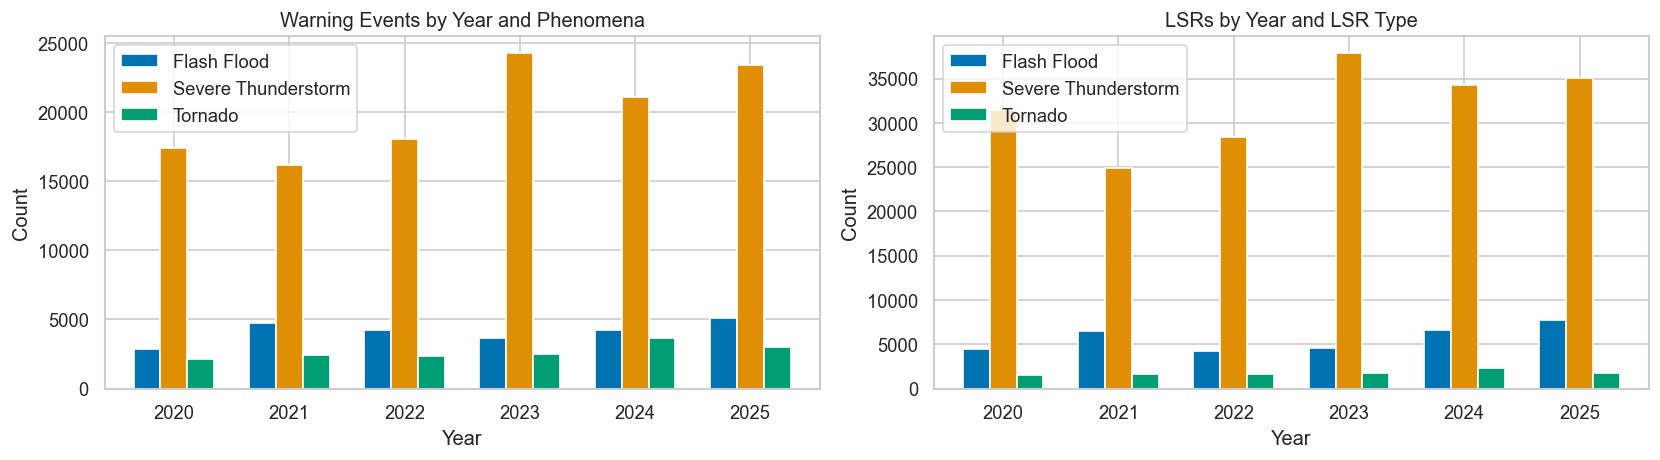

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)

for ax, df, grp, title in [
    (axes[0], events, "phenomena", "Warning Events by Year and Phenomena"),
    (axes[1], sr,     "lsrtype",   "LSRs by Year and LSR Type"),
]:
    counts = df.groupby(["year", grp]).size().unstack()
    counts.rename(columns=PHENOMENA_LABELS).plot(kind="bar", ax=ax, width=0.7)
    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=0)
    ax.legend(title=None)

plt.tight_layout()
plt.savefig(IMG_DIR / "eda_01_dataset_overview.png", bbox_inches="tight")
plt.show()

## 2. WFO Volume Distribution

Per-WFO mean annual event counts over the 2020–2024 baseline, by phenomena.
The p75 cutoff (dashed red line) marks the top-quartile threshold used in all
subsequent WFO-level analysis. Offices below this line are included only in the
sensitivity check.

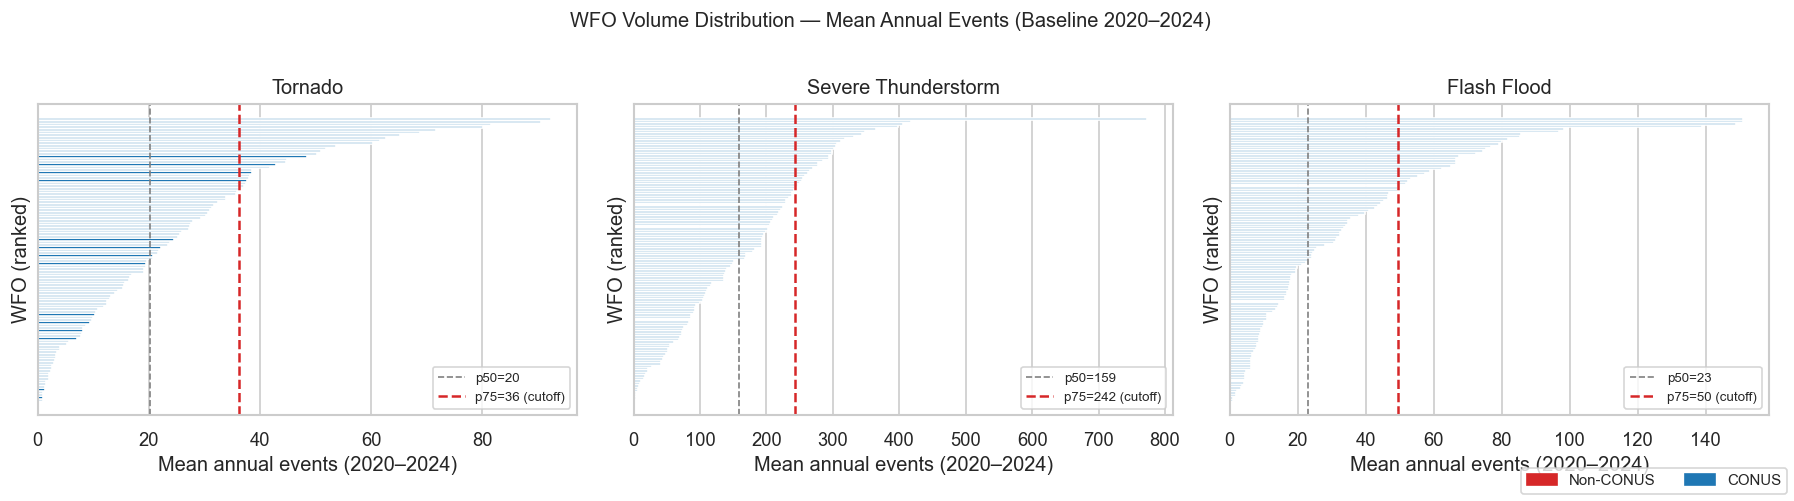

Tornado                    median=20/yr  p75=36/yr  top-quartile: 27 WFOs
Severe Thunderstorm        median=159/yr  p75=242/yr  top-quartile: 29 WFOs
Flash Flood                median=23/yr  p75=50/yr  top-quartile: 29 WFOs


In [4]:
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, phen in zip(axes, ["TO", "SV", "FF"]):
    sub = wfo_baseline[wfo_baseline["phenomena"] == phen].sort_values("mean_annual_events")
    colors = ["#d62728" if nc else "#1f77b4" for nc in sub["non_conus"]]
    ax.barh(range(len(sub)), sub["mean_annual_events"], color=colors, height=0.8)
    ax.set_title(PHENOMENA_LABELS[phen])
    ax.set_xlabel("Mean annual events (2020–2024)")
    ax.set_ylabel("WFO (ranked)")
    ax.set_yticks([])
    p50 = np.percentile(sub["mean_annual_events"], 50)
    p75 = np.percentile(sub["mean_annual_events"], 75)
    ax.axvline(p50, color="gray",    linestyle="--", linewidth=1,   label=f"p50={p50:.0f}")
    ax.axvline(p75, color="#d62728", linestyle="--", linewidth=1.5, label=f"p75={p75:.0f} (cutoff)")
    ax.legend(fontsize=8)

fig.legend(handles=[Patch(color="#d62728", label="Non-CONUS"),
                    Patch(color="#1f77b4", label="CONUS")],
           loc="lower right", ncol=2, fontsize=9)
plt.suptitle("WFO Volume Distribution — Mean Annual Events (Baseline 2020–2024)",
             y=1.01, fontsize=12)
plt.tight_layout()
plt.savefig(IMG_DIR / "eda_02_wfo_volume_distribution.png", bbox_inches="tight")
plt.show()

for phen in ["TO", "SV", "FF"]:
    sub = wfo_baseline[wfo_baseline["phenomena"] == phen]
    p75 = sub["mean_annual_events"].quantile(0.75)
    print(f"{PHENOMENA_LABELS[phen]:25s}  "
          f"median={sub.mean_annual_events.median():.0f}/yr  "
          f"p75={p75:.0f}/yr  "
          f"top-quartile: {len(p75_wfos[phen])} WFOs")

In [5]:

# Top 10 WFOs by mean annual event count for each phenomena (baseline 2020-2024)
for phen in ["TO", "SV", "FF"]:
    top = (
        wfo_baseline[wfo_baseline["phenomena"] == phen]
        .sort_values("mean_annual_events", ascending=False)
        .head(10)[["wfo", "mean_annual_events", "non_conus"]]
        .reset_index(drop=True)
    )
    top.index += 1
    top.columns = ["WFO", "Mean annual events", "Non-CONUS"]
    print(f"\n{'─'*40}")
    print(f"  {PHENOMENA_LABELS[phen]} — Top 10 WFOs by volume")
    print(f"{'─'*40}")
    print(top.to_string(index=True))



────────────────────────────────────────
  Tornado — Top 10 WFOs by volume
────────────────────────────────────────
    WFO  Mean annual events  Non-CONUS
1   TAE                92.4      False
2   OUN                90.6      False
3   SHV                81.6      False
4   JAN                80.2      False
5   LCH                71.6      False
6   LZK                68.8      False
7   MOB                65.2      False
8   LIX                62.6      False
9   PAH                61.6      False
10  MEG                60.4      False

────────────────────────────────────────
  Severe Thunderstorm — Top 10 WFOs by volume
────────────────────────────────────────
    WFO  Mean annual events  Non-CONUS
1   OUN               773.2      False
2   LWX               417.8      False
3   JAN               406.2      False
4   LZK               398.0      False
5   TSA               364.6      False
6   FWD               348.2      False
7   FFC               344.4      False
8   TAE      

## 3. Monthly Time Series — Top-Quartile WFOs

Monthly verify rate and mean lead time for top-quartile CONUS WFOs, plotted by
month of year. Each baseline year (2020–2024) is shown as a thin gray line;
2025 is shown in red. This separates the seasonal cycle from year-over-year
change and makes 2025 directly comparable to each prior year.

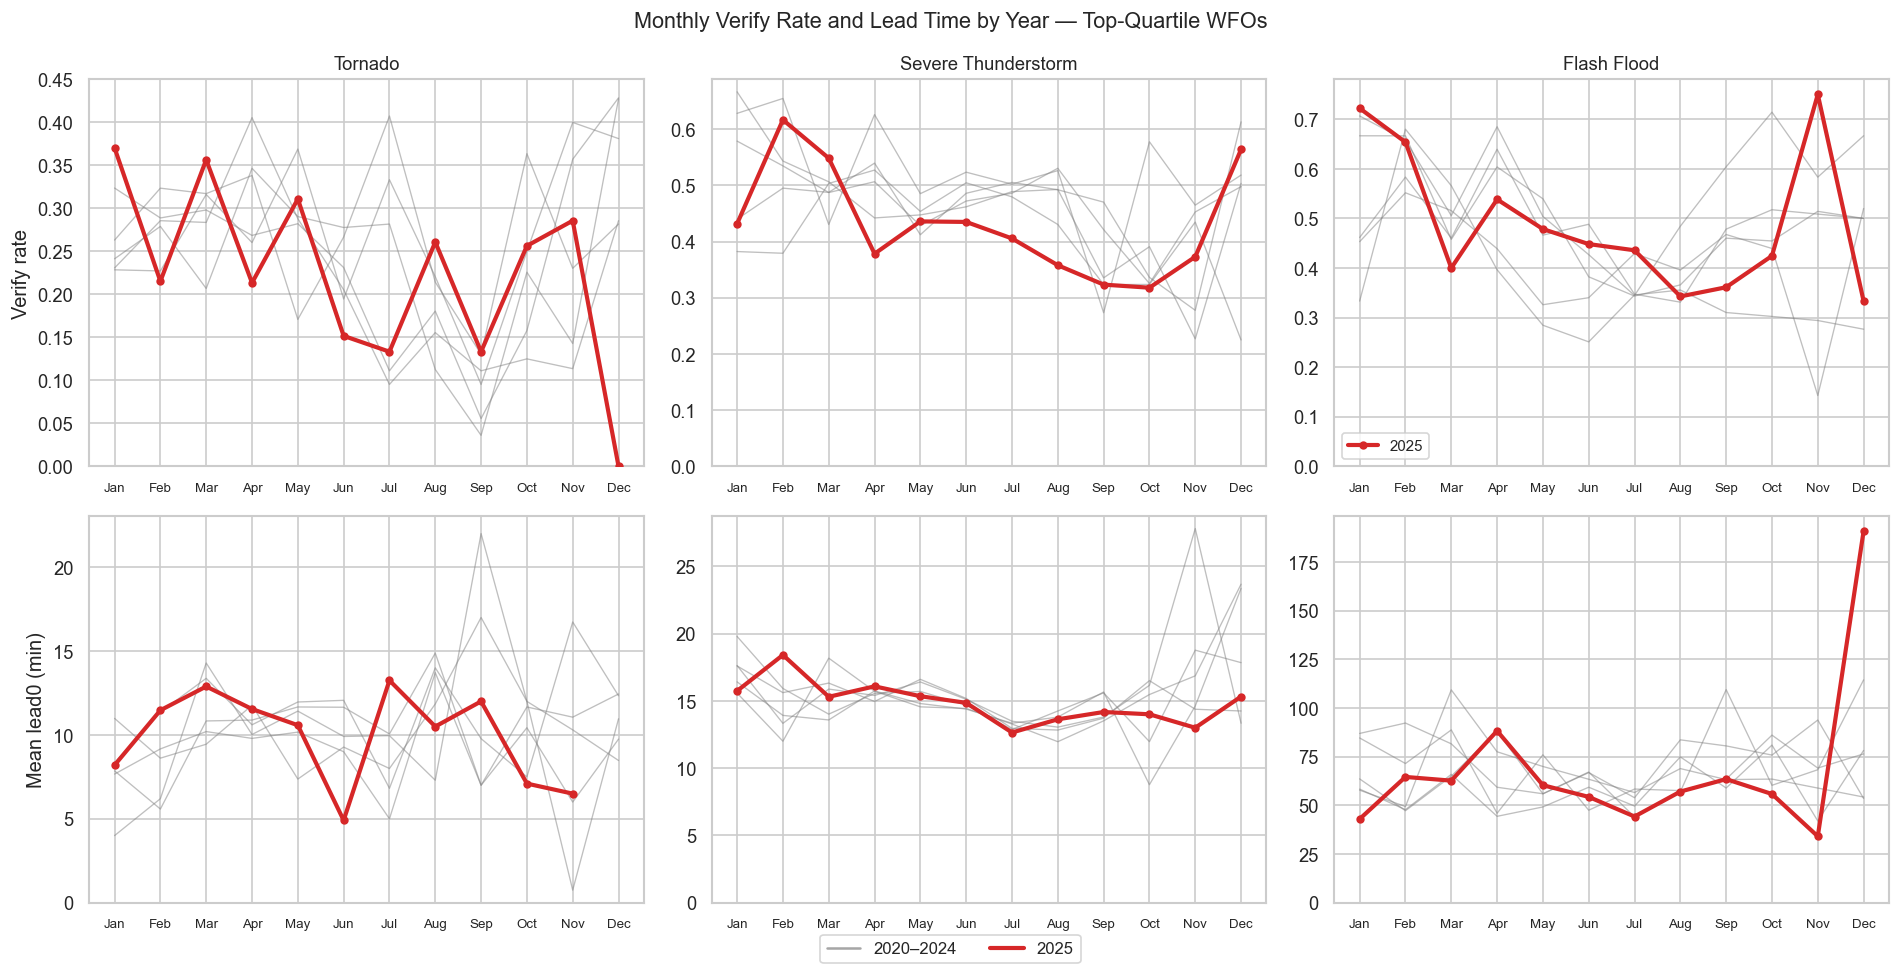

In [6]:
def monthly_agg(phen):
    """Pool top-quartile WFOs for this phenomena, aggregate by year and month."""
    mask = events["wfo"].isin(p75_wfos[phen]) & (events["phenomena"] == phen)
    return (
        events[mask]
        .groupby(["year", "year_month"])
        .agg(n_events=("verify", "count"),
             verify_rate=("verify", "mean"),
             mean_lead0=("lead0", "mean"))
        .reset_index()
        .assign(phenomena=phen, month=lambda d: d["year_month"].dt.month)
        .sort_values(["year", "month"])
    )

monthly = pd.concat([monthly_agg(p) for p in ["TO", "SV", "FF"]], ignore_index=True)

baseline_years = [2020, 2021, 2022, 2023, 2024]
month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for col, phen in enumerate(["TO", "SV", "FF"]):
    sub = monthly[monthly["phenomena"] == phen]

    for row, (metric, ylabel) in enumerate([
        ("verify_rate", "Verify rate"),
        ("mean_lead0",  "Mean lead0 (min)"),
    ]):
        ax = axes[row, col]

        for yr in baseline_years:
            yr_data = sub[sub["year"] == yr].sort_values("month")
            ax.plot(yr_data["month"], yr_data[metric],
                    color="gray", linewidth=0.8, alpha=0.5)

        yr25 = sub[sub["year"] == 2025].sort_values("month")
        ax.plot(yr25["month"], yr25[metric],
                color="#d62728", linewidth=2.5, marker="o",
                markersize=4, label="2025", zorder=5)

        ax.set_xticks(range(1, 13))
        ax.set_xticklabels(month_labels, fontsize=8)
        ax.set_ylim(0, None)
        ax.set_ylabel(ylabel if col == 0 else "")
        if row == 0:
            ax.set_title(PHENOMENA_LABELS[phen], fontsize=11)
        if col == 2 and row == 0:
            ax.legend(fontsize=9)

from matplotlib.lines import Line2D
baseline_handle = Line2D([0], [0], color="gray", linewidth=1.5, alpha=0.7, label="2020–2024")
treatment_handle = Line2D([0], [0], color="#d62728", linewidth=2.5, label="2025")
fig.legend(handles=[baseline_handle, treatment_handle],
           loc="lower center", ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.02))

fig.suptitle("Monthly Verify Rate and Lead Time by Year — Top-Quartile WFOs",
             fontsize=13)
plt.tight_layout()
plt.savefig(IMG_DIR / "eda_03_monthly_time_series.png", bbox_inches="tight")
plt.show()

## 4. Seasonal Envelope: 2025 vs. Baseline — Top-Quartile WFOs

The 2020–2024 monthly mean ± 1 SD forms the expected seasonal envelope for
top-quartile WFOs. Overlaying 2025 shows whether each month falls within or
outside historical norms, isolating the staffing signal from the seasonal cycle.

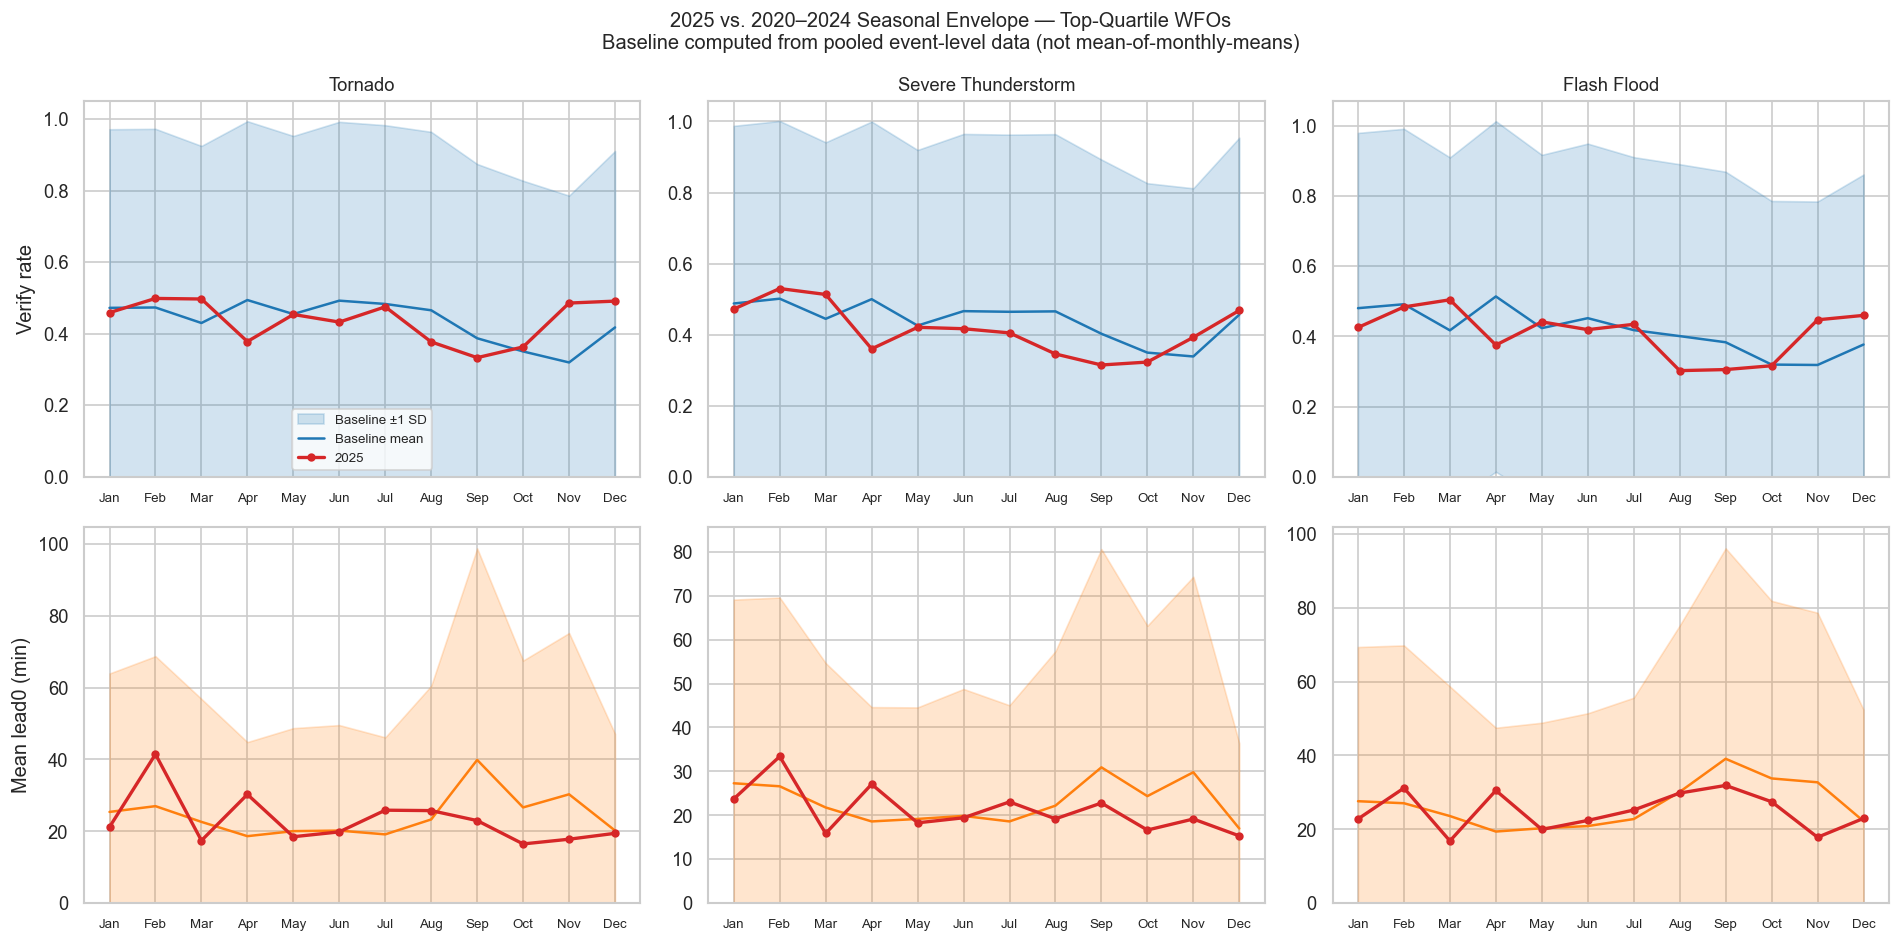

In [7]:
# Build seasonal envelope directly from event-level data (pooled across baseline years)
# This avoids double-weighting low-volume months that distort mean-of-monthly-means

def seasonal_envelope(phen):
    mask = events["wfo"].isin(p75_wfos[phen]) & (events["issue"].dt.year <= 2024)
    df = events[mask].copy()
    df["month"] = df["issue"].dt.month
    return (
        df.groupby("month")
        .agg(
            mean_vr = ("verify",  "mean"),
            std_vr  = ("verify",  "std"),
            mean_l0 = ("lead0",   "mean"),
            std_l0  = ("lead0",   "std"),
            n       = ("verify",  "count"),
        )
        .reset_index()
        .assign(phenomena=phen)
    )

def seasonal_2025(phen):
    mask = events["wfo"].isin(p75_wfos[phen]) & (events["issue"].dt.year == 2025)
    df = events[mask].copy()
    df["month"] = df["issue"].dt.month
    return (
        df.groupby("month")
        .agg(
            verify_rate = ("verify", "mean"),
            mean_lead0  = ("lead0",  "mean"),
            n           = ("verify", "count"),
        )
        .reset_index()
        .assign(phenomena=phen)
    )

env_all  = pd.concat([seasonal_envelope(p) for p in ["TO", "SV", "FF"]], ignore_index=True)
t25_all  = pd.concat([seasonal_2025(p)     for p in ["TO", "SV", "FF"]], ignore_index=True)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]

for col, phen in enumerate(["TO", "SV", "FF"]):
    env = env_all[env_all["phenomena"] == phen].sort_values("month")
    t25 = t25_all[t25_all["phenomena"] == phen].sort_values("month")

    for row, (mean_col, std_col, t25_col, ylabel, color) in enumerate([
        ("mean_vr", "std_vr", "verify_rate", "Verify rate",      "#1f77b4"),
        ("mean_l0", "std_l0", "mean_lead0",  "Mean lead0 (min)", "#ff7f0e"),
    ]):
        ax = axes[row, col]
        ax.fill_between(env["month"],
                        env[mean_col] - env[std_col],
                        env[mean_col] + env[std_col],
                        alpha=0.2, color=color, label="Baseline ±1 SD")
        ax.plot(env["month"], env[mean_col], color=color,
                linewidth=1.5, label="Baseline mean")
        ax.plot(t25["month"], t25[t25_col],
                color="#d62728", linewidth=2, marker="o",
                markersize=4, label="2025")
        ax.set_xticks(range(1, 13))
        ax.set_xticklabels(month_labels, fontsize=8)
        ax.set_ylim(0, None)
        ax.set_ylabel(ylabel if col == 0 else "")
        if row == 0:
            ax.set_title(PHENOMENA_LABELS[phen], fontsize=11)
        if col == 0 and row == 0:
            ax.legend(fontsize=8)

fig.suptitle("2025 vs. 2020–2024 Seasonal Envelope — Top-Quartile WFOs\n"
             "Baseline computed from pooled event-level data (not mean-of-monthly-means)",
             fontsize=12)
plt.tight_layout()
plt.savefig(IMG_DIR / "eda_04_seasonal_envelope.png", bbox_inches="tight")
plt.show()

## 5. WFO-Level Annual Outcomes

Per-WFO verify rate computed annually. Each WFO's 2025 value is compared to
its own 2020–2024 mean — a within-office before/after that controls for
persistent climatological and geographic differences.

Analysis is restricted to **top-quartile WFOs by baseline event volume**
(p75+ mean annual events, 2020–2024) to ensure per-office metrics are
statistically reliable. A sensitivity check compares results against all
CONUS WFOs.

| Phenomena | p75 threshold | Top-quartile WFOs |
|---|---|---|
| Tornado | ≥36/yr | 27 offices |
| Severe Thunderstorm | ≥242/yr | 29 offices |
| Flash Flood | ≥50/yr | 29 offices |

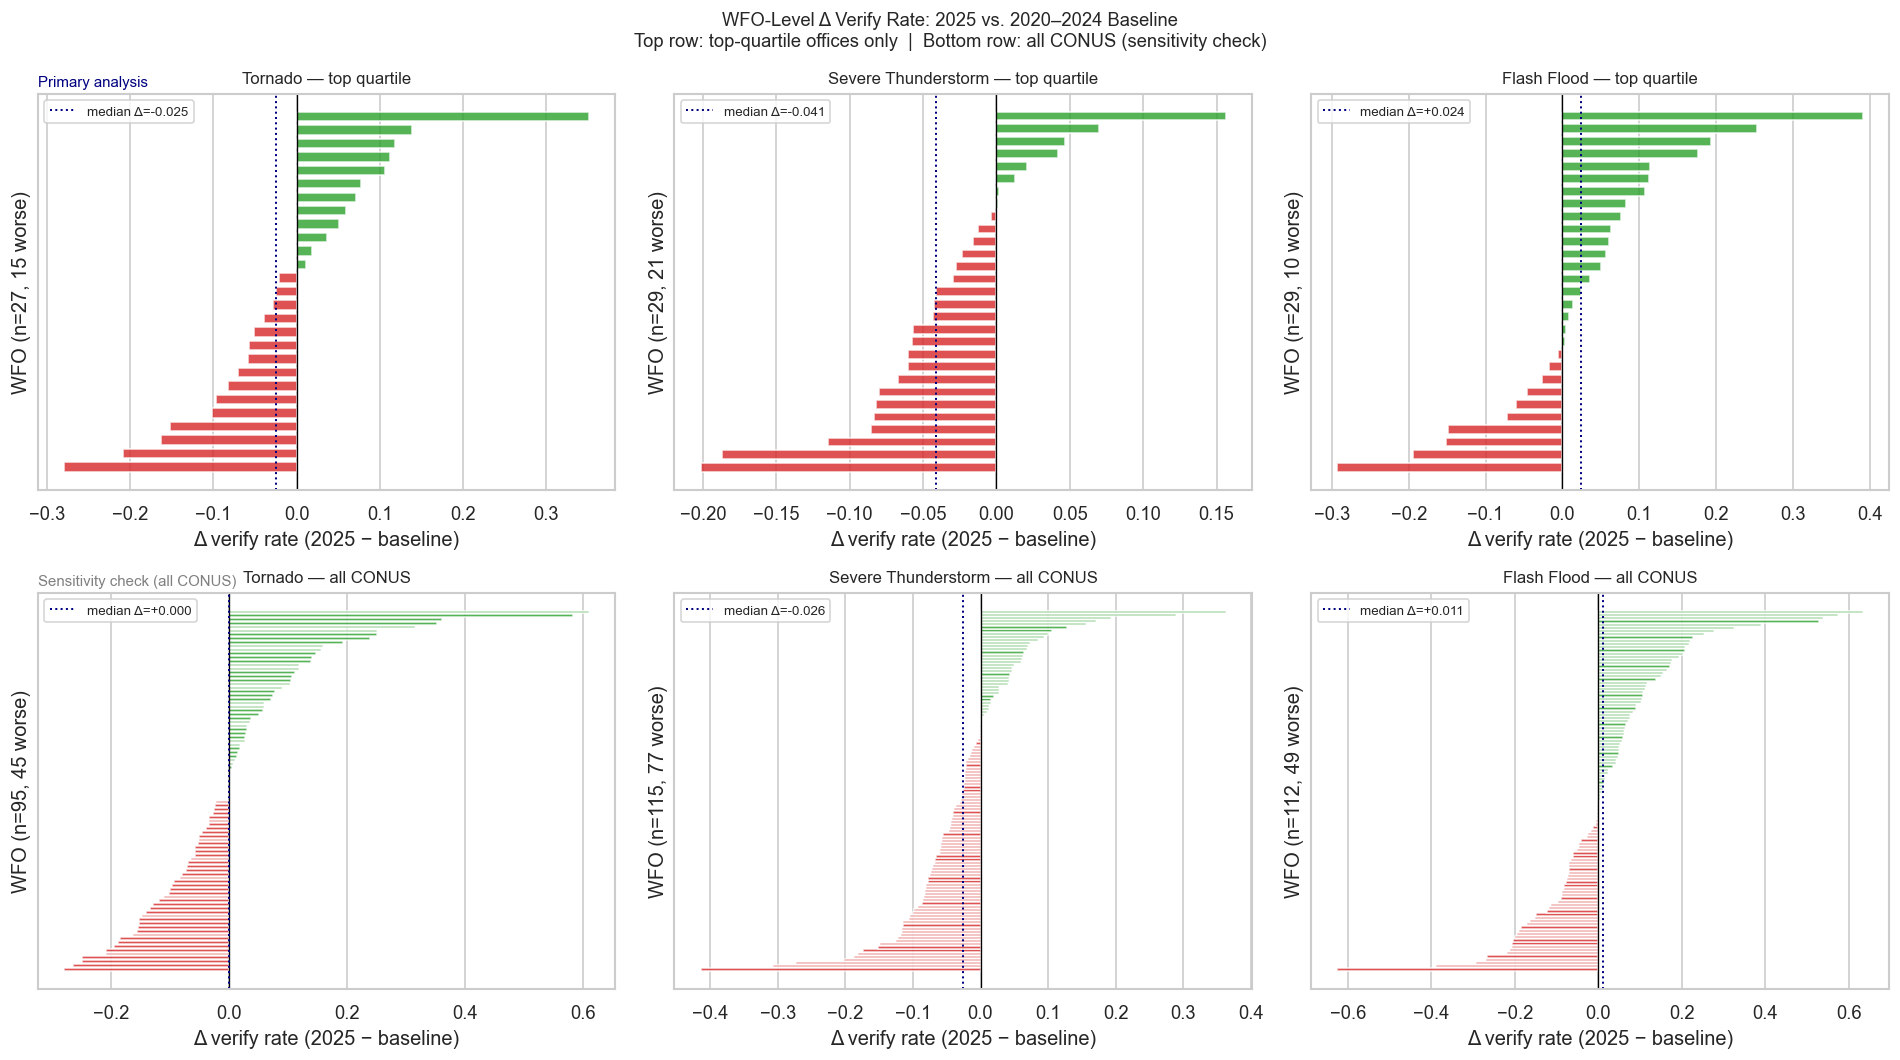

Phenomena                 Set                   n WFOs   Median Δ  # Worse
───────────────────────────────────────────────────────────────────────────
Tornado                   top quartile              27     -0.025       15
Tornado                   all CONUS                 95     +0.000       45
Severe Thunderstorm       top quartile              29     -0.041       21
Severe Thunderstorm       all CONUS                115     -0.026       77
Flash Flood               top quartile              29     +0.024       10
Flash Flood               all CONUS                112     +0.011       49


In [8]:
wfo_verify = (
    events[~events["wfo"].isin(NON_CONUS)]
    .groupby(["wfo", "year", "phenomena"])
    .agg(
        n_events    = ("verify", "count"),
        verify_rate = ("verify", "mean"),
    )
    .reset_index()
)

wfo_baseline_vr = (
    wfo_verify[wfo_verify["year"] <= 2024]
    .groupby(["wfo", "phenomena"])
    .agg(
        baseline_mean = ("verify_rate", "mean"),
        baseline_std  = ("verify_rate", "std"),
        baseline_n    = ("n_events",    "mean"),
    )
    .reset_index()
)

wfo_2025 = (
    wfo_verify[wfo_verify["year"] == 2025]
    [["wfo", "phenomena", "verify_rate", "n_events"]]
    .rename(columns={"verify_rate": "vr_2025", "n_events": "n_2025"})
)

wfo_compare = wfo_baseline_vr.merge(wfo_2025, on=["wfo", "phenomena"], how="inner")
wfo_compare["delta"] = wfo_compare["vr_2025"] - wfo_compare["baseline_mean"]

def delta_plot(ax, phen, subset_mask, title_suffix=""):
    sub = wfo_compare[wfo_compare["phenomena"] == phen]
    if subset_mask is not None:
        sub = sub[sub["wfo"].isin(subset_mask)]
    sub = sub.sort_values("delta")
    colors = ["#d62728" if d < 0 else "#2ca02c" for d in sub["delta"]]
    ax.barh(range(len(sub)), sub["delta"], color=colors, height=0.7, alpha=0.8)
    ax.axvline(0, color="black", linewidth=0.8)
    med = sub["delta"].median()
    ax.axvline(med, color="navy", linestyle=":", linewidth=1.2,
               label=f"median Δ={med:+.3f}")
    ax.set_title(f"{PHENOMENA_LABELS[phen]}{title_suffix}", fontsize=10)
    ax.set_xlabel("Δ verify rate (2025 − baseline)")
    ax.set_yticks([])
    ax.legend(fontsize=8)
    n_neg = (sub["delta"] < 0).sum()
    ax.set_ylabel(f"WFO (n={len(sub)}, {n_neg} worse)")

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for col, phen in enumerate(["TO", "SV", "FF"]):
    delta_plot(axes[0, col], phen, p75_wfos[phen], " — top quartile")
    delta_plot(axes[1, col], phen, None,            " — all CONUS")

axes[0, 0].annotate("Primary analysis", xy=(0, 1.02), xycoords="axes fraction",
                    fontsize=9, color="navy")
axes[1, 0].annotate("Sensitivity check (all CONUS)", xy=(0, 1.02),
                    xycoords="axes fraction", fontsize=9, color="gray")

plt.suptitle("WFO-Level Δ Verify Rate: 2025 vs. 2020–2024 Baseline\n"
             "Top row: top-quartile offices only  |  Bottom row: all CONUS (sensitivity check)",
             fontsize=11)
plt.tight_layout()
plt.savefig(IMG_DIR / "eda_05_wfo_delta_verify_rate.png", bbox_inches="tight")
plt.show()

print(f"{'Phenomena':<25} {'Set':<20} {'n WFOs':>7} {'Median Δ':>10} {'# Worse':>8}")
print("─" * 75)
for phen in ["TO", "SV", "FF"]:
    for label, mask in [("top quartile", p75_wfos[phen]), ("all CONUS", None)]:
        sub = wfo_compare[wfo_compare["phenomena"] == phen]
        if mask is not None:
            sub = sub[sub["wfo"].isin(mask)]
        print(f"{PHENOMENA_LABELS[phen]:<25} {label:<20} {len(sub):>7} "
              f"{sub['delta'].median():>+10.3f} {(sub['delta']<0).sum():>8}")

## Analysis Notes

All WFO-level findings below apply to **top-quartile offices** (p75+ baseline
volume) unless otherwise noted. Sensitivity checks against all CONUS offices
appear in Section 5.

Findings to carry into `05_analysis.ipynb`:

- The **seasonal envelope** (Section 4) shows whether 2025 monthly metrics at
  high-volume WFOs fall inside or outside historical norms. Months that breach
  the ±1 SD band are candidates for formal testing.
- The **WFO-level delta plot** (Section 5) shows the distribution of per-office
  2025 vs. baseline change. Widespread negative deltas across top-quartile
  offices — which have the volume to produce reliable estimates — is more
  consistent with a systemic effect than a few noisy outliers.
- **SV is the primary phenomena of interest:** sufficient volume for WFO-level
  monthly analysis, broadest negative delta signal, and stable enough baselines
  to detect real change.
- **TO and FF:** Annual WFO-level analysis is viable for top-quartile offices;
  monthly resolution is noisier. Results should be interpreted with more caution.
- **Next steps:** event-level logistic regression with WFO fixed effects and
  month-of-year fixed effects to formally test whether 2025 verify rate differs
  after controlling for seasonal and office-level confounders; restricted to
  top-quartile WFOs with all-CONUS sensitivity check.

## 6. Case Study: Goodland, KS (GLD)

Goodland (GLD) is the only NWS office documented by name in contemporaneous
reporting as having **lost 24/7 operations** during the treatment period. The
Washington Post (May 16, 2025) identified GLD as one of the hardest-hit offices;
by October 2025 its vacancy rate stood at 41%, up from 32% under the prior
administration (December 2025 WaPo). GLD was seeking to fill three senior
meteorologist positions as of May 2025.

GLD is in the **top quartile for both SV and TO** by baseline event volume
(SV rank 16/119, ~294.8/yr; TO rank 24/107, ~37.6/yr). It is also the first
WFO documented to have lost 24/7 operations, making it the closest available
proxy for a high-dose treatment unit in our dataset.

This section shows GLD's annual verify rate and mean lead time against the
top-quartile median for SV and TO, with the treatment timeline annotated.

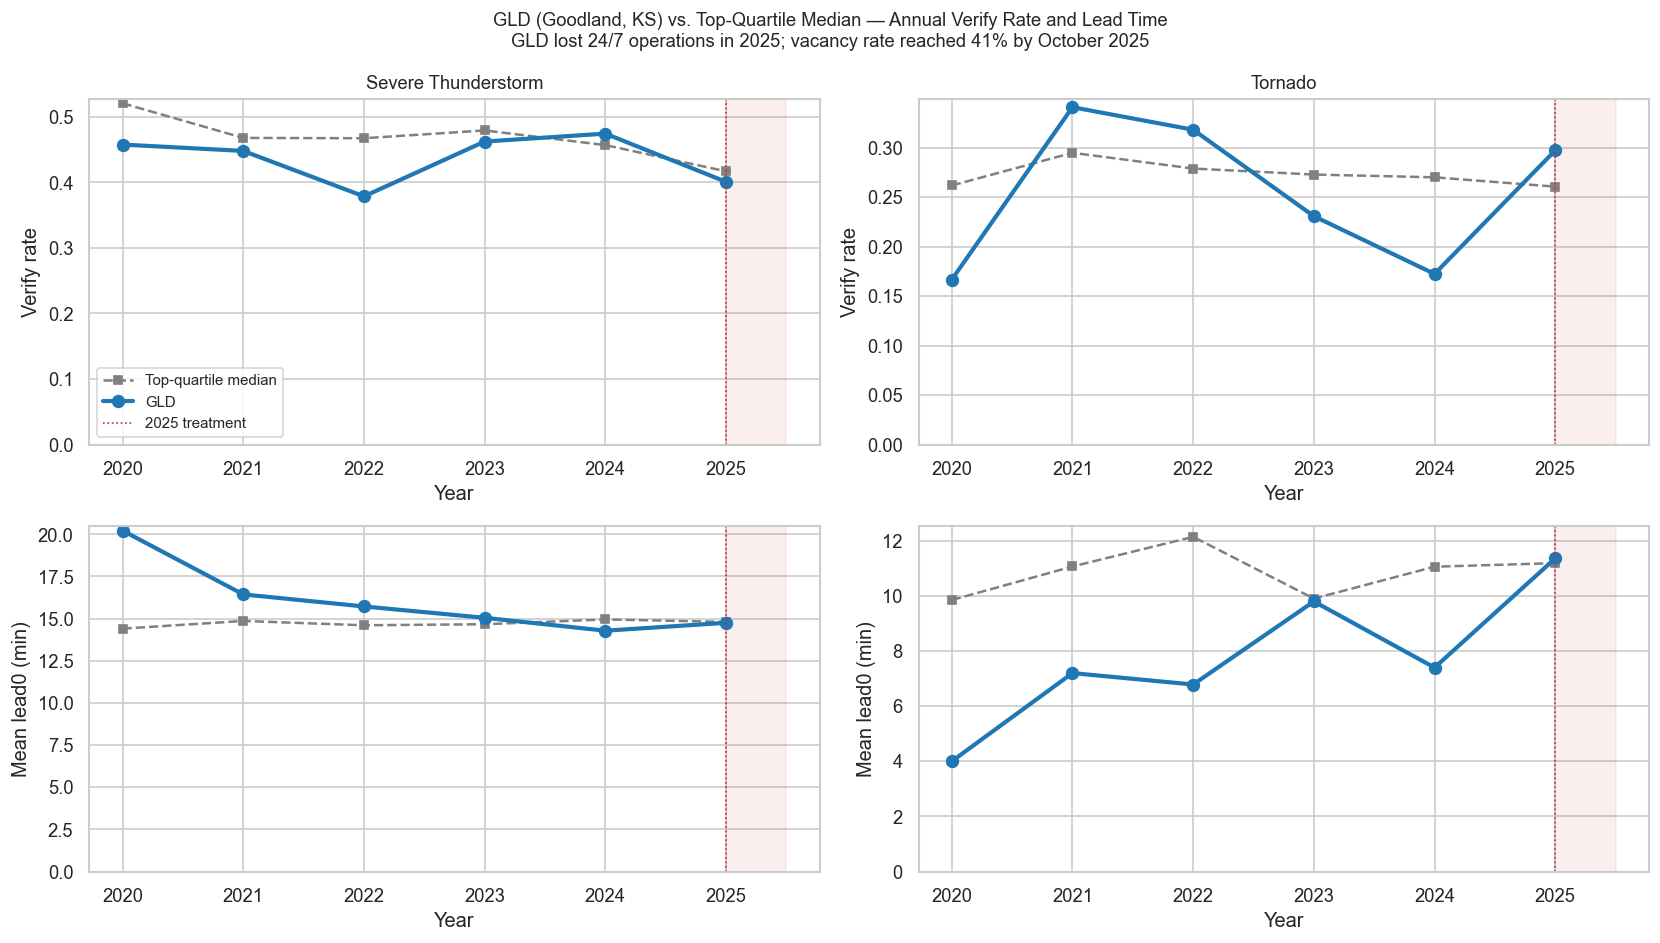

──────────────────────────────────────────────────────────────────────
  GLD Summary vs. Top-Quartile Median
──────────────────────────────────────────────────────────────────────
Phenomena              Metric                Baseline mean     2025    Delta
──────────────────────────────────────────────────────────────────────
  GLD  Severe Thunderstorm Verify rate                   0.444    0.401   -0.043
  p75  Severe Thunderstorm Verify rate                   0.479    0.417   -0.062
  GLD  Severe Thunderstorm Lead0 (min)                  16.341   14.750   -1.591
  p75  Severe Thunderstorm Lead0 (min)                  14.697   14.804   +0.107

  GLD  Tornado           Verify rate                   0.246    0.297   +0.052
  p75  Tornado           Verify rate                   0.276    0.261   -0.015
  GLD  Tornado           Lead0 (min)                   7.037   11.364   +4.326
  p75  Tornado           Lead0 (min)                  10.806   11.191   +0.385



In [9]:
gld_phens = ["SV", "TO"]

# ── Annual metrics: GLD vs. top-quartile median ───────────────────────────
def annual_metrics(phen, wfo_set):
    mask = events["wfo"].isin(wfo_set) & (events["phenomena"] == phen)
    return (
        events[mask]
        .groupby("year")
        .agg(verify_rate=("verify", "mean"), mean_lead0=("lead0", "mean"),
             n_events=("verify", "count"))
        .reset_index()
        .assign(phenomena=phen)
    )

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]

for col, phen in enumerate(gld_phens):
    gld   = annual_metrics(phen, {"GLD"})
    p75   = annual_metrics(phen, p75_wfos[phen])

    for row, (metric, ylabel) in enumerate([
        ("verify_rate", "Verify rate"),
        ("mean_lead0",  "Mean lead0 (min)"),
    ]):
        ax = axes[row, col]

        ax.plot(p75["year"], p75[metric],
                color="gray", linewidth=1.5, linestyle="--",
                marker="s", markersize=5, label="Top-quartile median")
        ax.plot(gld["year"], gld[metric],
                color="#1f77b4", linewidth=2.5,
                marker="o", markersize=7, label="GLD")

        # Treatment timeline annotations
        ax.axvspan(2025, 2025.5, alpha=0.08, color="#d62728")
        ax.axvline(2025, color="#d62728", linestyle=":", linewidth=1,
                   label="2025 treatment")

        ax.set_xticks(range(2020, 2026))
        ax.set_xlabel("Year")
        ax.set_ylabel(ylabel)
        ax.set_ylim(0, None)
        if row == 0:
            ax.set_title(f"{PHENOMENA_LABELS[phen]}", fontsize=11)
        if row == 0 and col == 0:
            ax.legend(fontsize=9)

fig.suptitle("GLD (Goodland, KS) vs. Top-Quartile Median — Annual Verify Rate and Lead Time\n"
             "GLD lost 24/7 operations in 2025; vacancy rate reached 41% by October 2025",
             fontsize=11)
plt.tight_layout()
plt.savefig(IMG_DIR / "eda_06_gld_case_study.png", bbox_inches="tight")
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────
print(f"{'':─<70}")
print(f"  GLD Summary vs. Top-Quartile Median")
print(f"{'':─<70}")
print(f"{'Phenomena':<22} {'Metric':<20} {'Baseline mean':>14} {'2025':>8} {'Delta':>8}")
print(f"{'':─<70}")

for phen in gld_phens:
    gld_yr = annual_metrics(phen, {"GLD"})
    p75_yr = annual_metrics(phen, p75_wfos[phen])

    for metric, label in [("verify_rate", "Verify rate"), ("mean_lead0", "Lead0 (min)")]:
        gld_base = gld_yr[gld_yr["year"] <= 2024][metric].mean()
        gld_2025 = gld_yr[gld_yr["year"] == 2025][metric].values
        p75_base = p75_yr[p75_yr["year"] <= 2024][metric].mean()
        p75_2025 = p75_yr[p75_yr["year"] == 2025][metric].values

        gld_val  = gld_2025[0] if len(gld_2025) else float("nan")
        delta    = gld_val - gld_base

        print(f"  GLD  {PHENOMENA_LABELS[phen]:<17} {label:<20} {gld_base:>14.3f} "
              f"{gld_val:>8.3f} {delta:>+8.3f}")
        p75_val  = p75_2025[0] if len(p75_2025) else float("nan")
        p75_delta = p75_val - p75_base
        print(f"  p75  {PHENOMENA_LABELS[phen]:<17} {label:<20} {p75_base:>14.3f} "
              f"{p75_val:>8.3f} {p75_delta:>+8.3f}")
    print()

## 7. Overnight Closure Offices vs. Others

The Washington Post (May 16, 2025) named specific NWS offices that lost 24/7
operations during the treatment period. This is the closest available
approximation of a **treatment dose** variable — offices confirmed to have
lost overnight capacity vs. those that maintained it.

Offices confirmed as losing overnight coverage (from WaPo May 16 reporting
and subsequent coverage):

| WFO | Location | Status as of May 2025 |
|---|---|---|
| GLD | Goodland, KS | Already closed overnight |
| JKL | Jackson, KY | Already closed overnight |
| HNX | Hanford, CA | Already closed overnight |
| STO | Sacramento, CA | Already closed overnight |
| CYS | Cheyenne, WY | Starting May 18 |
| PAH | Paducah, KY | Reduced staffing (portable toilet incident) |
| MQT | Marquette, MI | Starting May 18 |

This section compares 2025 verify rate deltas between overnight-closure offices
and all other top-quartile offices, for each phenomena where closure offices
have sufficient representation.

Overnight-closure offices present in wfo_compare by phenomena:
  Tornado                   top-quartile closure offices: ['GLD', 'PAH']
  Severe Thunderstorm       top-quartile closure offices: ['GLD', 'PAH']
  Flash Flood               top-quartile closure offices: ['PAH']


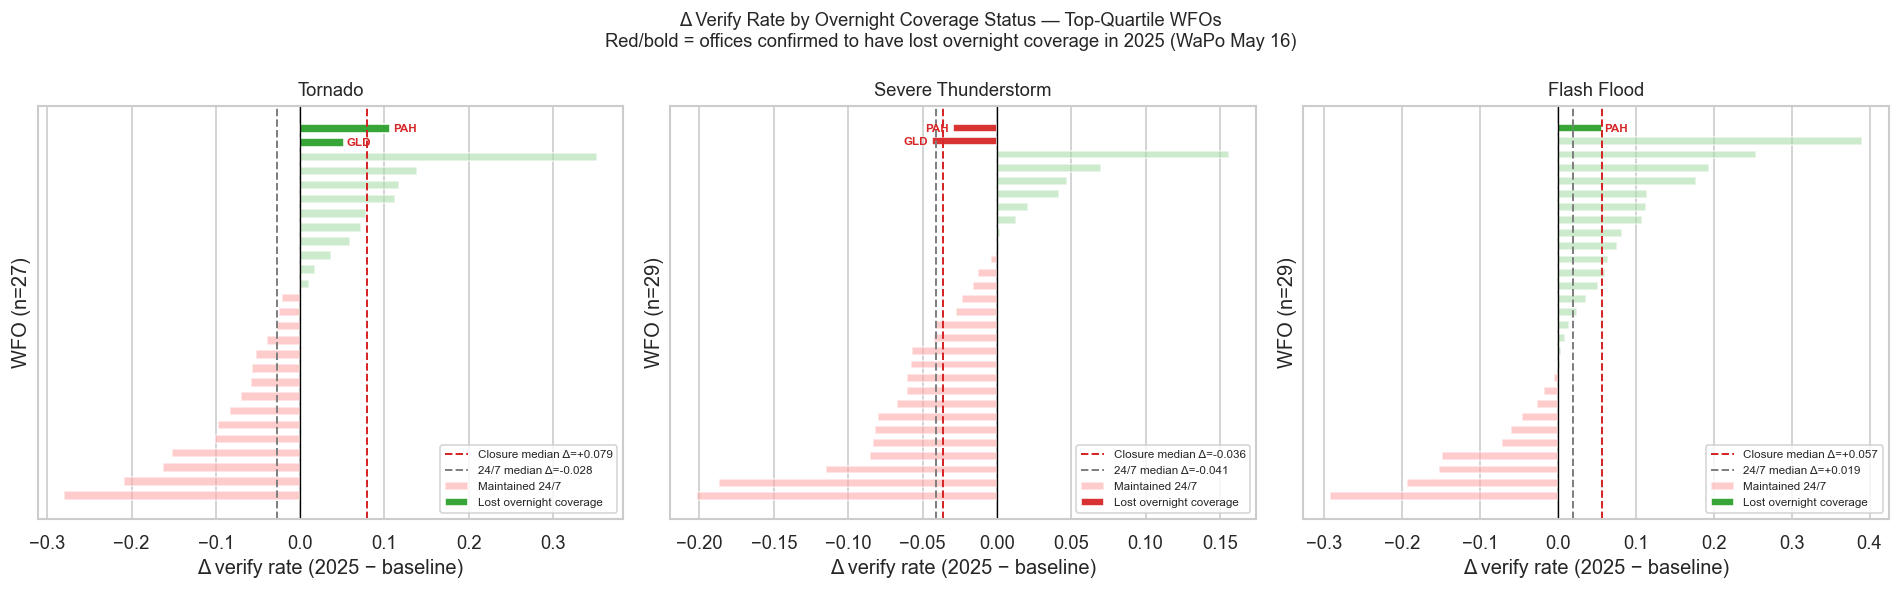


Phenomena                 Group                        n   Median Δ  # Worse
───────────────────────────────────────────────────────────────────────────
  Tornado                 Lost overnight coverage      2     +0.079        0
  Tornado                 Maintained 24/7             25     -0.028       15
  Severe Thunderstorm     Lost overnight coverage      2     -0.036        2
  Severe Thunderstorm     Maintained 24/7             27     -0.041       19
  Flash Flood             Lost overnight coverage      1     +0.057        0
  Flash Flood             Maintained 24/7             28     +0.019       10


In [10]:
# Offices documented as losing overnight coverage (WaPo May 16 + subsequent reporting)
OVERNIGHT_CLOSED = {"GLD", "JKL", "HNX", "STO", "CYS", "PAH", "MQT"}

# ── Per-WFO deltas with closure flag ─────────────────────────────────────
wfo_compare["overnight_closed"] = wfo_compare["wfo"].isin(OVERNIGHT_CLOSED)

print("Overnight-closure offices present in wfo_compare by phenomena:")
for phen in ["TO", "SV", "FF"]:
    sub = wfo_compare[wfo_compare["phenomena"] == phen]
    closed_in_p75 = sub[sub["wfo"].isin(p75_wfos[phen]) & sub["overnight_closed"]]["wfo"].tolist()
    print(f"  {PHENOMENA_LABELS[phen]:<25} top-quartile closure offices: {sorted(closed_in_p75)}")

# ── Delta comparison plot ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, phen in zip(axes, ["TO", "SV", "FF"]):
    sub = wfo_compare[
        (wfo_compare["phenomena"] == phen) &
        (wfo_compare["wfo"].isin(p75_wfos[phen]))
    ].copy()

    closed = sub[sub["overnight_closed"]].sort_values("delta")
    open_  = sub[~sub["overnight_closed"]].sort_values("delta")

    # Plot open offices as background bars (light gray)
    ax.barh(range(len(open_)), open_["delta"],
            color=["#ffaaaa" if d < 0 else "#aaddaa" for d in open_["delta"]],
            height=0.6, alpha=0.6, label="Maintained 24/7")

    # Overlay closure offices as bold colored bars
    y_offset = len(open_)
    ax.barh(range(y_offset, y_offset + len(closed)), closed["delta"],
            color=["#d62728" if d < 0 else "#2ca02c" for d in closed["delta"]],
            height=0.6, alpha=0.95, label="Lost overnight coverage")

    # Add WFO labels for closure offices
    for i, (_, row) in enumerate(closed.iterrows()):
        ax.text(row["delta"] + (0.003 if row["delta"] >= 0 else -0.003),
                y_offset + i,
                row["wfo"], va="center",
                ha="left" if row["delta"] >= 0 else "right",
                fontsize=7, fontweight="bold", color="#d62728")

    ax.axvline(0, color="black", linewidth=0.8)

    # Median lines for each group
    if len(closed) > 0:
        med_closed = closed["delta"].median()
        ax.axvline(med_closed, color="#d62728", linestyle="--", linewidth=1.2,
                   label=f"Closure median Δ={med_closed:+.3f}")
    if len(open_) > 0:
        med_open = open_["delta"].median()
        ax.axvline(med_open, color="gray", linestyle="--", linewidth=1.2,
                   label=f"24/7 median Δ={med_open:+.3f}")

    ax.set_title(PHENOMENA_LABELS[phen], fontsize=11)
    ax.set_xlabel("Δ verify rate (2025 − baseline)")
    ax.set_yticks([])
    ax.set_ylabel(f"WFO (n={len(sub)})")
    ax.legend(fontsize=7, loc="lower right")

fig.suptitle("Δ Verify Rate by Overnight Coverage Status — Top-Quartile WFOs\n"
             "Red/bold = offices confirmed to have lost overnight coverage in 2025 (WaPo May 16)",
             fontsize=11)
plt.tight_layout()
plt.savefig(IMG_DIR / "eda_07_overnight_closure_delta.png", bbox_inches="tight")
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────
print(f"\n{'Phenomena':<25} {'Group':<25} {'n':>4} {'Median Δ':>10} {'# Worse':>8}")
print("─" * 75)
for phen in ["TO", "SV", "FF"]:
    sub = wfo_compare[
        (wfo_compare["phenomena"] == phen) &
        (wfo_compare["wfo"].isin(p75_wfos[phen]))
    ]
    for label, mask in [
        ("Lost overnight coverage", sub["overnight_closed"]),
        ("Maintained 24/7",        ~sub["overnight_closed"]),
    ]:
        grp = sub[mask]
        if len(grp) == 0:
            continue
        print(f"  {PHENOMENA_LABELS[phen]:<23} {label:<25} {len(grp):>4} "
              f"{grp['delta'].median():>+10.3f} {(grp['delta']<0).sum():>8}")

## 8. False Alarm Ratio and POD — Top-Quartile WFOs

Verify rate alone is ambiguous: a drop could mean **fewer true events warned**
(worse POD) or **fewer false alarms issued** (better FAR). This section
separates the two using the standard contingency table:

| | Event occurred | No event |
|---|---|---|
| **Warning issued** | Hit | False alarm |
| **No warning** | Miss | Correct negative |

- **FAR** (warning-based) = false alarms / (hits + false alarms) = 1 − verify_rate  
- **POD** (LSR-based) = warned LSRs / total LSRs = `sr.warned.mean()` per phenomena  
- **Warning volume** = total warnings issued per year

A verify rate drop driven by **higher FAR** means more speculative warnings
(volume up, hits unchanged). A drop driven by **lower POD** means fewer true
events were warned (misses increased). These have opposite implications for
whether staffing cuts degraded performance.

Note: LSR-based POD is subject to underreporting bias — fewer LSRs filed in
2025 would inflate `warned` fraction mechanically. Volume trends should be
interpreted alongside POD.

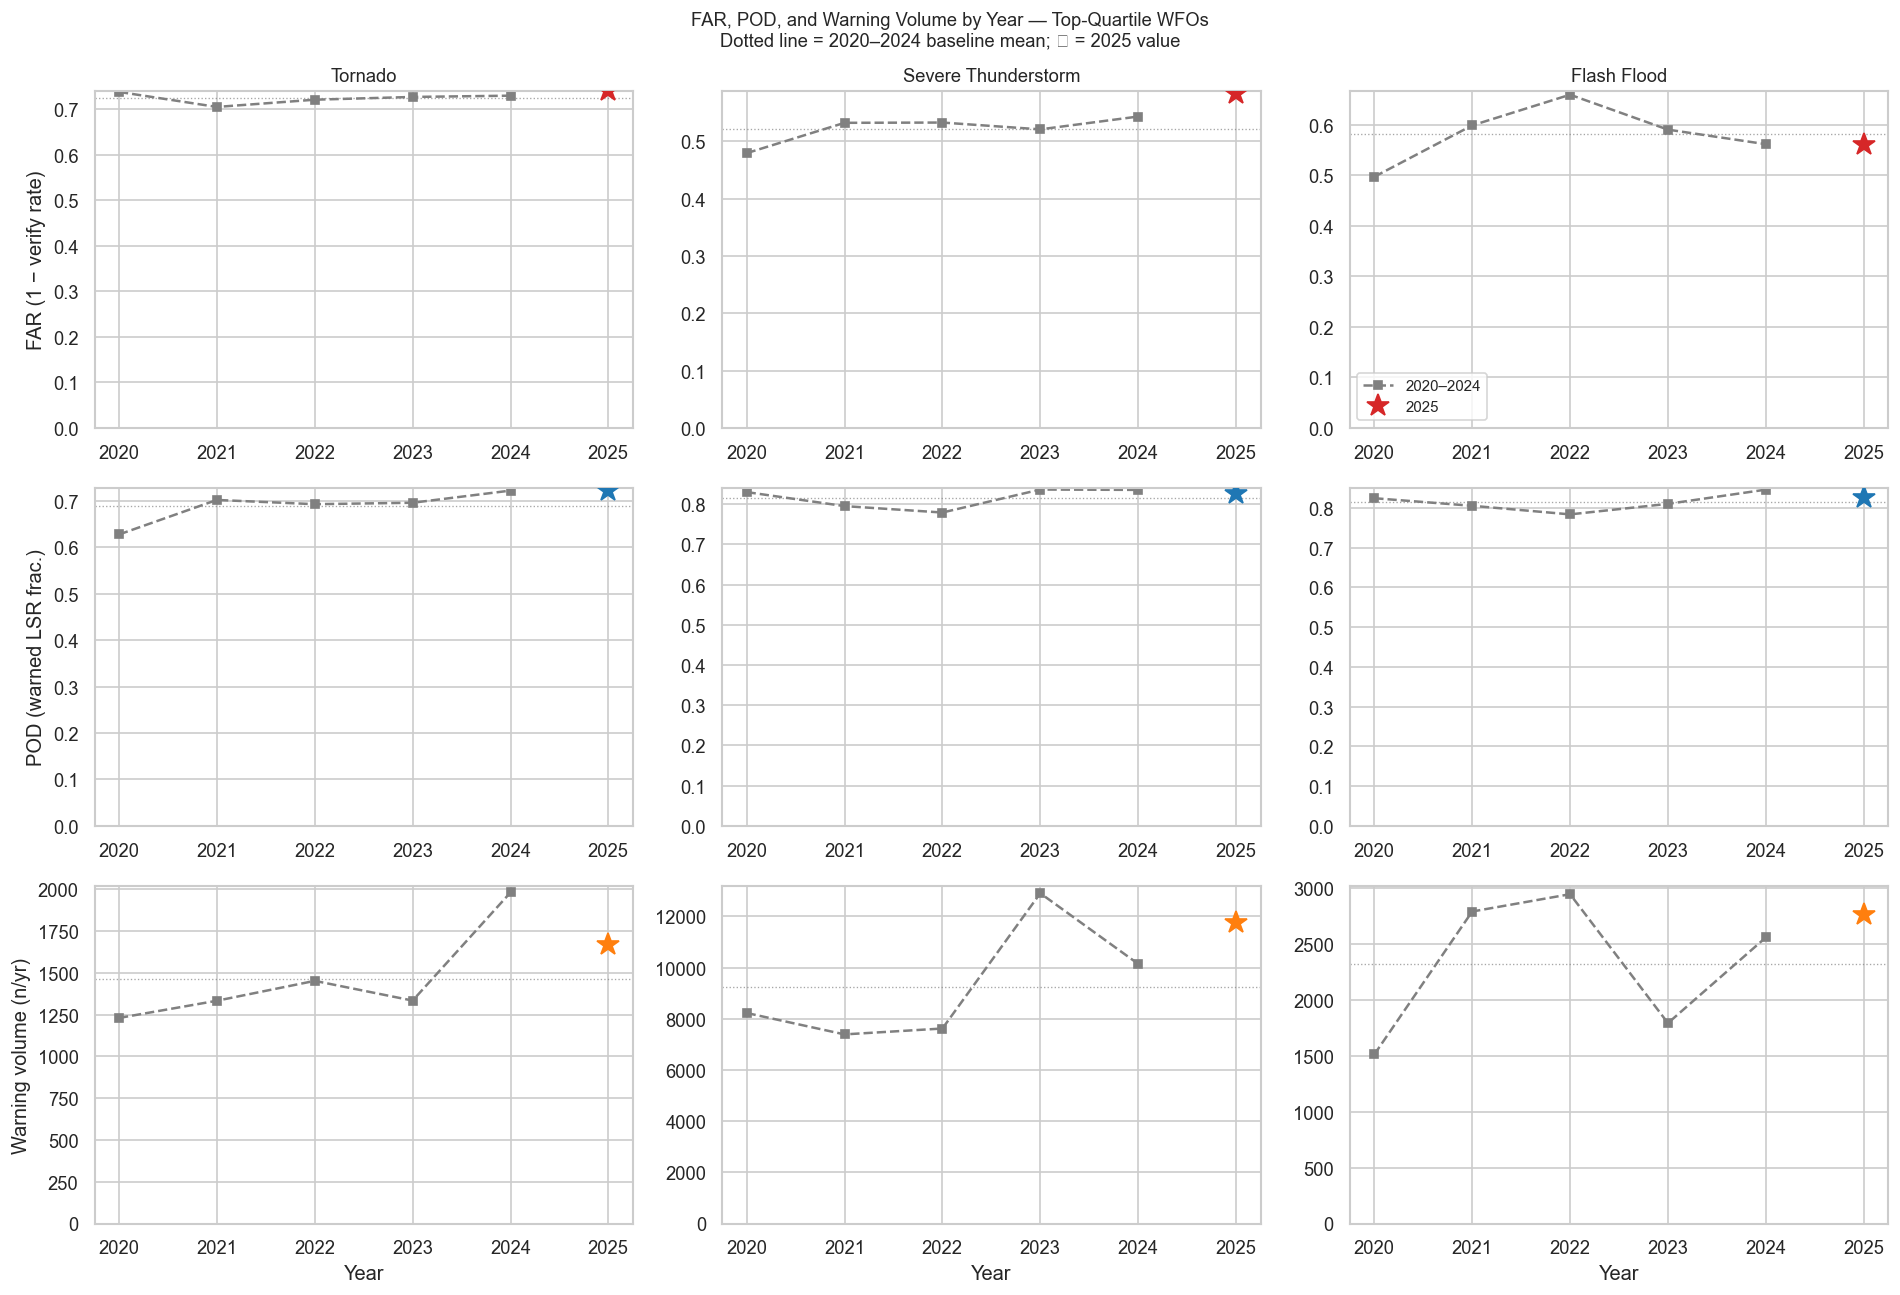

Phenomena                 Metric                  Baseline mean       2025      Delta
─────────────────────────────────────────────────────────────────────────────────────
  Tornado                 FAR (1 − verify rate)           0.724      0.739     +0.015
  Tornado                 POD (warned LSR frac.)          0.689      0.721     +0.033
  Tornado                 Warning volume (n/yr)        1466.000   1669.000   +203.000

  Severe Thunderstorm     FAR (1 − verify rate)           0.521      0.583     +0.062
  Severe Thunderstorm     POD (warned LSR frac.)          0.815      0.825     +0.009
  Severe Thunderstorm     Warning volume (n/yr)        9258.800  11748.000  +2489.200

  Flash Flood             FAR (1 − verify rate)           0.581      0.560     -0.022
  Flash Flood             POD (warned LSR frac.)          0.814      0.826     +0.012
  Flash Flood             Warning volume (n/yr)        2321.800   2766.000   +444.200



In [11]:
# ── Annual FAR, POD, and volume for top-quartile WFOs ────────────────────
def annual_far_pod(phen):
    # Warning-side: FAR and volume from events table
    ev_mask = events["wfo"].isin(p75_wfos[phen]) & (events["phenomena"] == phen)
    ev_yr = (
        events[ev_mask]
        .groupby("year")
        .agg(
            n_warnings  = ("verify", "count"),
            n_verified  = ("verify", "sum"),
        )
        .reset_index()
        .assign(
            far        = lambda d: 1 - d["n_verified"] / d["n_warnings"],
            verify_rate= lambda d: d["n_verified"] / d["n_warnings"],
        )
    )
    # LSR-side: POD and LSR volume from stormreports table
    sr_mask = sr["wfo"].isin(p75_wfos[phen]) & (sr["lsrtype"] == phen) & (~sr["tdq"])
    sr_yr = (
        sr[sr_mask]
        .groupby("year")
        .agg(
            n_lsrs  = ("warned", "count"),
            n_warned= ("warned", "sum"),
        )
        .reset_index()
        .assign(pod = lambda d: d["n_warned"] / d["n_lsrs"])
    )
    return ev_yr.merge(sr_yr, on="year"), phen

results = {p: annual_far_pod(p) for p in ["TO", "SV", "FF"]}

# ── Plot: 3 rows (FAR, POD, volume) × 3 cols (phenomena) ─────────────────
fig, axes = plt.subplots(3, 3, figsize=(16, 11))

metrics = [
    ("far",         "FAR (1 − verify rate)",   "#d62728"),
    ("pod",         "POD (warned LSR frac.)",   "#1f77b4"),
    ("n_warnings",  "Warning volume (n/yr)",    "#ff7f0e"),
]

for col, phen in enumerate(["TO", "SV", "FF"]):
    df, _ = results[phen]
    baseline = df[df["year"] <= 2024]
    yr2025   = df[df["year"] == 2025]

    for row, (metric, ylabel, color) in enumerate(metrics):
        ax = axes[row, col]

        ax.plot(baseline["year"], baseline[metric],
                color="gray", linewidth=1.5, linestyle="--",
                marker="s", markersize=5, label="2020–2024")
        if len(yr2025):
            ax.plot(yr2025["year"], yr2025[metric],
                    color=color, linewidth=0, marker="*",
                    markersize=14, label="2025", zorder=5)

        # Baseline mean reference line
        base_mean = baseline[metric].mean()
        ax.axhline(base_mean, color="gray", linestyle=":", linewidth=0.8, alpha=0.7)

        ax.set_xticks(range(2020, 2026))
        ax.set_xlabel("Year" if row == 2 else "")
        ax.set_ylabel(ylabel if col == 0 else "")
        ax.set_ylim(0, None)
        if row == 0:
            ax.set_title(PHENOMENA_LABELS[phen], fontsize=11)
        if row == 0 and col == 2:
            ax.legend(fontsize=9)

fig.suptitle("FAR, POD, and Warning Volume by Year — Top-Quartile WFOs\n"
             "Dotted line = 2020–2024 baseline mean; ★ = 2025 value",
             fontsize=11)
plt.tight_layout()
plt.savefig(IMG_DIR / "eda_08_far_pod_volume.png", bbox_inches="tight")
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────
print(f"{'Phenomena':<25} {'Metric':<22} {'Baseline mean':>14} {'2025':>10} {'Delta':>10}")
print("─" * 85)
for phen in ["TO", "SV", "FF"]:
    df, _ = results[phen]
    base = df[df["year"] <= 2024]
    t25  = df[df["year"] == 2025]
    if len(t25) == 0:
        continue
    for metric, label, _ in metrics:
        bm  = base[metric].mean()
        v25 = t25[metric].values[0]
        print(f"  {PHENOMENA_LABELS[phen]:<23} {label:<22} {bm:>14.3f} {v25:>10.3f} {v25-bm:>+10.3f}")
    print()